In [61]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
import numpy as np
import matplotlib.pyplot as plt

import networkx as nx
from networkx.algorithms import smallworld
import random
from collections import Counter
from scipy.spatial import cKDTree

from tqdm import tqdm

In [63]:
from src.neuron_population import NeuronPopulation
from src.connectome import Connectome
from src.overhead import Simulation
from src.neuron_templates import neuron_type_IZ
from src.network_grower import *
from src.network_generators import *
from src.neuron_type_distributor import *
from src.network_weight_distributor import *
from src.external_inputs import *

In [64]:
excitatory_type = "ss4"
inhibitory_type = "b"

In [65]:
seed = 1234

## Create network

In [66]:
n_neurons = 200

compartment_names = ["in", "out"]

normalize_target_out_E_in = 2.0
normalize_target_out_I_in = 1000.0
normalize_target_out_E_out = 2.0
normalize_target_out_I_out = 1000.0

compartment_params = {
    "in": {"type_fractions": {"ss4": 0.8, "b": 0.2}, 
           "inhibitory_types": ("b",), 
           "p0_by_pair": {"EE": 0.5, "EI": 0.5, "IE": 0.5, "II": 0.5},
           "mu_E": 1.0, "sigma_E": 1.6, "mu_I": 30.0, "sigma_I": 6.0,
           "lambda_by_preclass": {"E": 0.2, "I": 0.05},
           "weight_dist_by_ntype": {"ss4": "lognormal", "b": "normal"},
           "outdegree_config_by_type": {
                "ss4": {"dist": "lognormal", "params": (2.65, 0.8)},
                "b":   {"dist": "neg-bin", "params": (50, 40)},
            },
           "normalize_mode": "out",
           "normalize_target_out_E": normalize_target_out_E_in,
           "normalize_target_out_I": normalize_target_out_I_in,
           "weight_clip": (1e-4, 100.0),
           "distance_scale": 20.0,
    },
    
    
    "out": {"type_fractions": {"ss4": 0.8, "b": 0.2}, 
           "inhibitory_types": ("b",), 
           "p0_by_pair": {"EE": 0.5, "EI": 0.5, "IE": 0.5, "II": 0.5}, 
           "mu_E": 1.0, "sigma_E": 1.6, "mu_I": 60.0, "sigma_I": 6.0,
           "lambda_by_preclass": {"E": 0.2, "I": 0.2},
           "weight_dist_by_ntype": {"ss4": "lognormal", "b": "normal"},
           "outdegree_config_by_type": {
                "ss4": {"dist": "lognormal", "params": (2.65, 0.8)},
                "b":   {"dist": "neg-bin", "params": (50, 40)},
            },
           "normalize_mode": "out",
           "normalize_target_out_E": normalize_target_out_E_out,
           "normalize_target_out_I": normalize_target_out_I_out,
           "weight_clip": (1e-4, 100.0),
           "distance_scale": 20.0,
    },
}

inter_distance_scale = 1.0
compartment_distribution = {"in": 0.5, "out": 0.5}

inter_compartment_matrix=[[0, 0.4],
                          [0.01, 0]]

inter_weight_pair_scale = {"EE": 1.0, "EI": 0.0, "IE": 4.0, "II": 0.0}

# compartment_distance_matrix=[[0.0, inter_distance_scale],
#                              [inter_distance_scale, 0.0]]

compartment_centers = {
    "in": (0.0, 0.0),
    "out": (20.0, 0.0),
}

inter_distance_jitter=0.15



G = generate_multi_compartment_spatial_ei_network(
    n_total_neurons=n_neurons,
    compartment_names=compartment_names,
    compartment_params=compartment_params,
    compartment_distribution=compartment_distribution,
    inter_distance_scale=inter_distance_scale,
    inter_compartment_matrix=inter_compartment_matrix,
    inter_weight_pair_scale=inter_weight_pair_scale,
    compartment_centers=compartment_centers,
    inter_distance_jitter=inter_distance_jitter,
    # compartment_distance_matrix=compartment_distance_matrix,

)

## Inspect network

Text(0.5, 1.0, 'b Weight Distribution after Lognormal Redistribution')

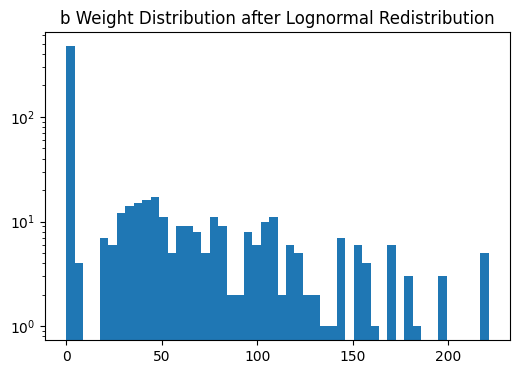

In [67]:
# Plot ss4 weight distribution
n_test_type = "b"
weights = [G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['ntype'] == n_test_type and G.nodes[u]["compartment"] == "in"]
plt.figure(figsize=(6,4))
plt.hist(weights, bins=50, log=True)
plt.title(f"{n_test_type} Weight Distribution after Lognormal Redistribution")

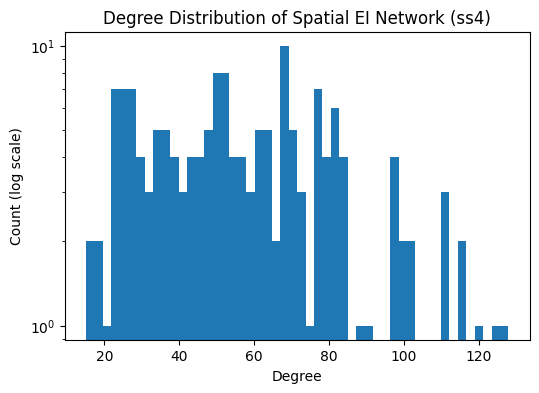

In [68]:
# Plot degree distribution
n_type_show = "ss4"
degrees = [G.degree(n) for n in G.nodes() if G.nodes[n]['ntype'] == n_type_show]
plt.figure(figsize=(6,4))
plt.hist(degrees, bins=50, log=True)
plt.title(f"Degree Distribution of Spatial EI Network ({n_type_show})")
plt.xlabel("Degree")
plt.ylabel("Count (log scale)")
plt.show()

In [69]:
enable_plot = False

if enable_plot:
    # Plot graph G using "pos" attribute for node positions
    pos = nx.get_node_attributes(G, 'pos')
    # Edge thinckness proportional to weight
    edges = G.edges()
    weights = [G[u][v]['weight'] / 200.0 for u, v in edges]
    # Node size proportional to degree
    degrees = [G.degree(n) for n in G.nodes()]
    # Node color by neuron type
    ntypes = nx.get_node_attributes(G, 'ntype')
    # Map neuron types to colors
    color_map = {'ss4': 'blue', 'b': 'red'}
    node_colors = [color_map.get(ntypes[n], 'gray') for n in G.nodes()]
    # Edge alpha
    alphas = [0.2 + 0.8 * G[u][v]['weight'] / 10.0 for u, v in edges]
    plt.figure(figsize=(8,8))
    nx.draw(G, pos, node_size=degrees, width=weights, edge_cmap=plt.cm.viridis, node_color=node_colors, alpha=0.65, with_labels=False)
    plt.title("Spatial EI Network Visualization")
    plt.show()

Total inter-compartment weight: 1142.20
Total intra-compartment weight: 40320.00


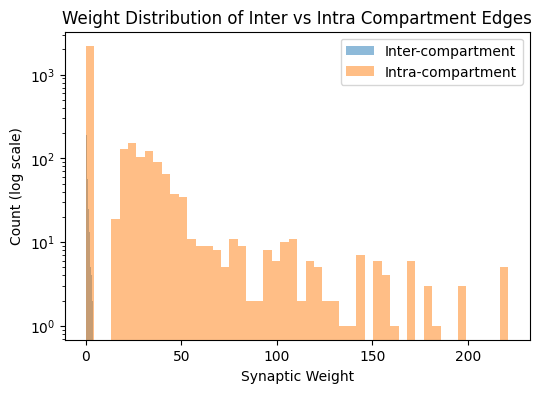

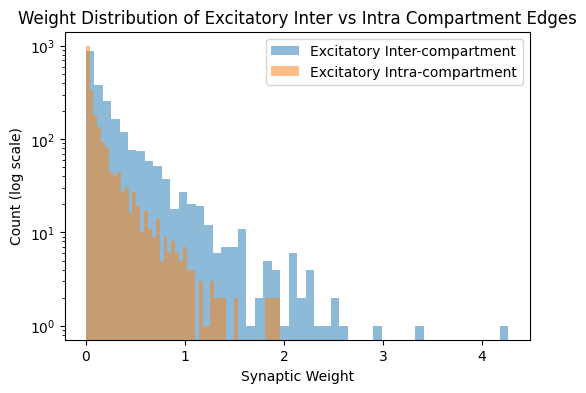

In [70]:
# Weight distribution of edges between compartments
inter_compartment_edges = {(u, v): G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] != G.nodes[v]['compartment']}
intra_compartment_edges = {(u, v): G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] == G.nodes[v]['compartment']}

# Total sum
total_inter_weight = sum(inter_compartment_edges.values())
total_intra_weight = sum(intra_compartment_edges.values())
print(f"Total inter-compartment weight: {total_inter_weight:.2f}")
print(f"Total intra-compartment weight: {total_intra_weight:.2f}")

# Plot distribution of inter vs intra compartment weights
plt.figure(figsize=(6,4))
plt.hist(list(inter_compartment_edges.values()), bins=50, alpha=0.5, label='Inter-compartment', log=True)
plt.hist(list(intra_compartment_edges.values()), bins=50, alpha=0.5, label='Intra-compartment', log=True)
plt.title("Weight Distribution of Inter vs Intra Compartment Edges")
plt.xlabel("Synaptic Weight")
plt.ylabel("Count (log scale)")
plt.legend()
plt.show()

# Plot where the presynaptic neurons are only exctiatory
exc_inter_compartment_edges = {(u, v): G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] != G.nodes[v]['compartment'] and G.nodes[u]['ntype'] == 'ss4'}
exc_intra_compartment_edges = {(u, v): G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] == G.nodes[v]['compartment'] and G.nodes[u]['ntype'] == 'ss4'}
plt.figure(figsize=(6,4))
plt.hist(list(exc_inter_compartment_edges.values()), bins=50, alpha=0.5, label='Excitatory Inter-compartment', log=True)
plt.hist(list(exc_intra_compartment_edges.values()), bins=50, alpha=0.5, label='Excitatory Intra-compartment', log=True)
plt.title("Weight Distribution of Excitatory Inter vs Intra Compartment Edges")
plt.xlabel("Synaptic Weight")
plt.ylabel("Count (log scale)")
plt.legend()
plt.show()

In [71]:
# Total sum of weights going from "in" compartment to "out" compartment
total_weight_in_to_out = sum(G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] == 'in' and G.nodes[v]['compartment'] == 'out')
print(f"Total weight from 'in' to 'out': {total_weight_in_to_out:.2f}")

# Total sum of weights going from "out" compartment to "in" compartment
total_weight_out_to_in = sum(G[u][v]['weight'] for u, v in G.edges() if G.nodes[u]['compartment'] == 'out' and G.nodes[v]['compartment'] == 'in')
print(f"Total weight from 'out' to 'in': {total_weight_out_to_in:.2f}")

Total weight from 'in' to 'out': 1100.79
Total weight from 'out' to 'in': 41.41


In [72]:
# Number of edges between in and out
num_edges_in_to_out = sum(1 for u, v in G.edges() if G.nodes[u]['compartment'] == 'in' and G.nodes[v]['compartment'] == 'out')
num_edges_out_to_in = sum(1 for u, v in G.edges() if G.nodes[u]['compartment'] == 'out' and G.nodes[v]['compartment'] == 'in')
print(f"Number of edges from 'in' to 'out': {num_edges_in_to_out}")
print(f"Number of edges from 'out' to 'in': {num_edges_out_to_in}")

# Number of edges within "in"
num_edges_in_to_in = sum(1 for u, v in G.edges() if G.nodes[u]['compartment'] == 'in' and G.nodes[v]['compartment'] == 'in')
print(f"Number of edges from 'in' to 'in': {num_edges_in_to_in}")

# Number of edges within "out"
num_edges_out_to_out = sum(1 for u, v in G.edges() if G.nodes[u]['compartment'] == 'out' and G.nodes[v]['compartment'] == 'out')
print(f"Number of edges from 'out' to 'out': {num_edges_out_to_out}")

Number of edges from 'in' to 'out': 2684
Number of edges from 'out' to 'in': 85
Number of edges from 'in' to 'in': 1384
Number of edges from 'out' to 'out': 1747


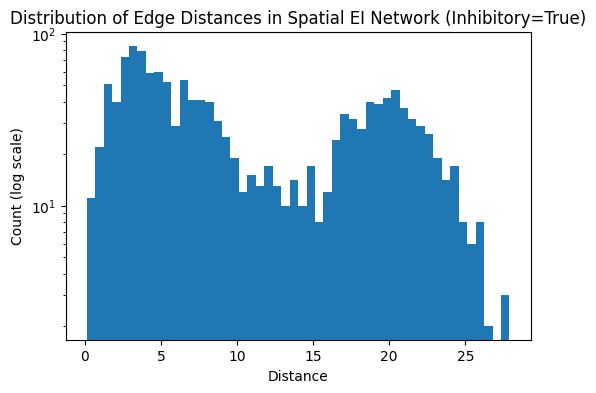

In [73]:
# Print distribution of "distance" attribute for edges
if_inhibitory = True
distances = [G[u][v]['distance'] for u, v in G.edges() if G.nodes[u]['inhibitory'] == if_inhibitory]
plt.figure(figsize=(6,4))
plt.hist(distances, bins=50, log=True)
plt.title(f"Distribution of Edge Distances in Spatial EI Network (Inhibitory={if_inhibitory})")
plt.xlabel("Distance")
plt.ylabel("Count (log scale)")
plt.show()

## Simulation Setup

In [74]:
dt = 0.1

In [75]:
# Neuron population parameters
n_neurons = G.number_of_nodes()
neuron_types = [excitatory_type, inhibitory_type]
n_neuron_types = len(neuron_types)
inhibitory = [False, True]
threshold_decay = np.exp(-dt / 5)

pop = NeuronPopulation(n_neurons, neuron_types, inhibitory, threshold_decay)

In [76]:
# Connectome
# Max number of outgoing synapses per neuron
max_synapses = max(dict(G.out_degree()).values())

connectome = Connectome(max_synapses, pop)

connectome.nx_to_connectome(G)

In [77]:
W_initial = connectome.W.copy()

In [78]:
nmda_weight = np.ones(connectome.neuron_population.n_neurons, dtype=float)
nmda_weight[pop.inhibitory_mask.astype(bool)] = 0.959685703507305 * 0.5

### Simulation function

In [79]:
def sim_w_input(sim, sim_len_ms, input_mask, input_rate, input_amp):
    poisson = PoissonInput(n_neurons, rate=input_rate * input_mask, amplitude=input_amp)
    steps = int(sim_len_ms / dt)
    for _ in tqdm(range(steps)):
        sim.step(spike_ext=poisson(dt), reward=1.0)

### Plastic mask

In [80]:
out_degrees = dict(G.out_degree())
top_neurons_plastic = sorted(out_degrees, key=out_degrees.get, reverse=True)
compartment_out_neurons = [n for n in top_neurons_plastic if G.nodes[n]['ntype'] == 'ss4']
p = 0.8
top_neurons_plastic = compartment_out_neurons[:int(p * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
random.shuffle(top_neurons_plastic)
length_top_neurons_plastic = len(top_neurons_plastic)
print(f"Top {p*100}% of excitatory neurons by out-degree for plasticity: {length_top_neurons_plastic} neurons")
# Check compartment distribution of top neurons
compartment_counts = Counter(G.nodes[n]['compartment'] for n in top_neurons_plastic)
print("Compartment distribution among top neurons:")
for compartment, count in compartment_counts.items():
    print(f"  {compartment}: {count} neurons")

plastic_mask = np.isin(np.arange(n_neurons), top_neurons_plastic)

Top 80.0% of excitatory neurons by out-degree for plasticity: 128 neurons
Compartment distribution among top neurons:
  out: 55 neurons
  in: 73 neurons


### Output config

In [81]:
# Choose top 20 % of neurons by out-degree in compartment "out"
out_degrees = dict(G.out_degree())
top_neurons_out = sorted(out_degrees, key=out_degrees.get, reverse=True)
compartment_out_neurons = [n for n in top_neurons_out if G.nodes[n]['compartment'] == 'out' and G.nodes[n]['ntype'] == 'ss4']
p_out = 1.0
top_neurons_out = compartment_out_neurons[:int(p_out * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
random.shuffle(top_neurons_out)
## Sort by position y coordinate
# top_neurons_out.sort(key=lambda n: G.nodes[n]['pos'][1])
length_top_neurons_out = len(top_neurons_out)
print(f"Top {p_out*100}% of excitatory neurons by out-degree in 'out' compartment: {length_top_neurons_out} neurons")
# Check neuron types of top neurons
top_neuron_types = [G.nodes[n]['ntype'] for n in top_neurons_out]
type_counts = Counter(top_neuron_types)
print("Neuron type distribution among top neurons:")
for ntype, count in type_counts.items():
    print(f"  {ntype}: {count} neurons")

Top 100.0% of excitatory neurons by out-degree in 'out' compartment: 80 neurons
Neuron type distribution among top neurons:
  ss4: 80 neurons


In [82]:
# Top half of output neurons
out_1 = top_neurons_out[:len(top_neurons_out) // 2]
out_2 = top_neurons_out[len(top_neurons_out) // 2:]

# Weight sum of connections within out_1, within out_2, and between out_1 and out_2
weight_out_1_to_out_1 = sum(G[u][v]['weight'] for u in out_1 for v in out_1 if G.has_edge(u, v))
weight_out_2_to_out_2 = sum(G[u][v]['weight'] for u in out_2 for v in out_2 if G.has_edge(u, v))
weight_out_1_to_out_2 = sum(G[u][v]['weight'] for u in out_1 for v in out_2 if G.has_edge(u, v))
print(f"Total weight from out_1 to out_1: {weight_out_1_to_out_1:.2f}")
print(f"Total weight from out_2 to out_2: {weight_out_2_to_out_2:.2f}")
print(f"Total weight from out_1 to out_2: {weight_out_1_to_out_2:.2f}")

Total weight from out_1 to out_1: 27.50
Total weight from out_2 to out_2: 30.16
Total weight from out_1 to out_2: 33.34


### Input config

In [83]:
# Choose top 20 % of neurons by out-degree in compartment "in"
out_degrees = dict(G.out_degree())
top_neurons_in = sorted(out_degrees, key=out_degrees.get, reverse=True)
compartment_out_neurons = [n for n in top_neurons_in if G.nodes[n]['compartment'] == 'in' and G.nodes[n]['ntype'] == 'ss4']
p = 0.2
top_neurons_in = compartment_out_neurons[:int(p * len(compartment_out_neurons))]
# Shuffle top neurons to avoid any ordering effects
# random.shuffle(top_neurons_in)
# Sort by position y coordinate
top_neurons_in.sort(key=lambda n: G.nodes[n]['pos'][1])
length_top_neurons_in = len(top_neurons_in)
print(f"Top {p*100}% of excitatory neurons by out-degree in 'in' compartment: {length_top_neurons_in} neurons")
# Check neuron types of top neurons
top_neuron_types = [G.nodes[n]['ntype'] for n in top_neurons_in]
type_counts = Counter(top_neuron_types)
print("Neuron type distribution among top neurons:")
for ntype, count in type_counts.items():
    print(f"  {ntype}: {count} neurons")
input_neurons_1 = top_neurons_in[int(0.5 * len(top_neurons_in)):]
input_neurons_2 = top_neurons_in[:int(0.5 * len(top_neurons_in))]

input_1_mask = np.zeros(n_neurons, dtype=bool)
input_2_mask = np.zeros(n_neurons, dtype=bool)

input_1_mask[input_neurons_1] = True
input_2_mask[input_neurons_2] = True

Top 20.0% of excitatory neurons by out-degree in 'in' compartment: 16 neurons
Neuron type distribution among top neurons:
  ss4: 16 neurons


### Resting potentials

In [84]:
resting_potentials = np.zeros(n_neurons)

for i in range(n_neurons):
    resting_potentials[i] = neuron_type_IZ[G.nodes[i]["ntype"]][5]

## Simulate

In [85]:
# top_neurons_out

100%|██████████| 20000/20000 [00:02<00:00, 9955.61it/s] 


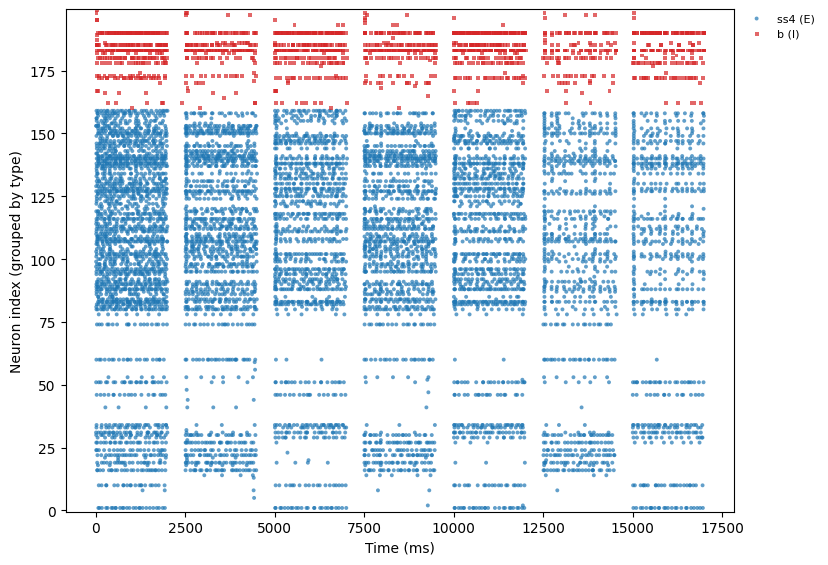

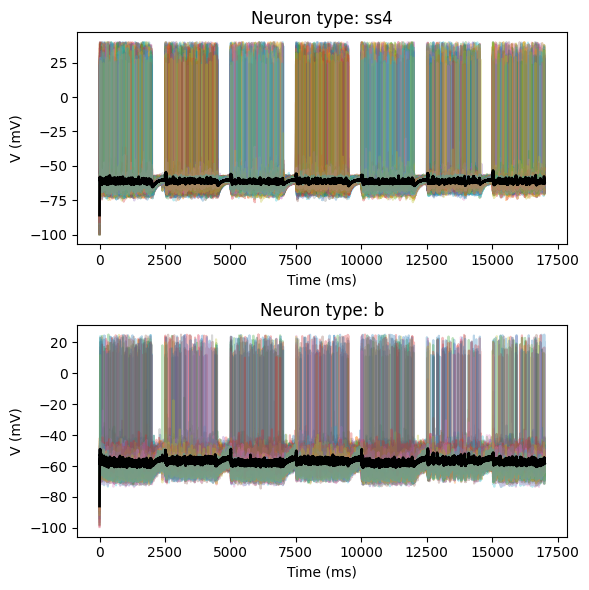

In [86]:
# Randomize initial voltages
Vs = rng.uniform(-100, -70, size=n_neurons)
us = rng.uniform(0, 400, size=n_neurons)
spikes = np.zeros(n_neurons, dtype=bool)
Ts = np.zeros_like(spikes, dtype=float)

state0 = (Vs,
          us,
          spikes.copy(),
          Ts.copy())


sim = Simulation(connectome, dt, stepper_type="euler_det", state0=state0,
                synapse_kwargs={"LT_scale": 1.0, "NMDA_weight": nmda_weight}, synapse_type="standard",
                 enable_debug_logger=False,
                 enable_plasticity=True, plasticity="clopath", plasticity_reward_type="online",
                 plasticity_kwargs={"plastic_source_mask": plastic_mask, "weight_multiplicity": None, 
                                    "max_weight": 100.0, "weight_update_scale": 0.1,
                                    # "enable_debug_logger": False, 
                                    "theta_minus": resting_potentials,
                                    "theta_plus": resting_potentials + 15.0
                                    })

sim.configure_output_readout(output_neuron_indices=top_neurons_out, output_dim=2, rate_window_ms=500.0,
                             enable_logger=True)

amplitude = 1.0
v_ext = 100.0

rounds = 5

out_neurons_1 = sim.output_readout["groups"][0]
out_neurons_2 = sim.output_readout["groups"][1]

# Append input_neurons_1 and out_neurons_1 to the same list
input_neurons_1_and_out_1 = np.concatenate((input_neurons_1, out_neurons_1))
input_neurons_2_and_out_2 = np.concatenate((input_neurons_2, out_neurons_2))

i1o1 = np.zeros(n_neurons, dtype=bool)
i1o1[input_neurons_1_and_out_1] = True
i2o2 = np.zeros(n_neurons, dtype=bool)
i2o2[input_neurons_2_and_out_2] = True

i1 = np.zeros(n_neurons, dtype=bool)
i1[input_neurons_1] = True
i2 = np.zeros(n_neurons, dtype=bool)
i2[input_neurons_2] = True

i1i2 = np.zeros(n_neurons, dtype=bool)
i1i2[input_neurons_1_and_out_1] = True
i1i2[input_neurons_2_and_out_2] = True

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i1i2, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i1o1, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i2o2, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i1o1, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i2o2, input_rate=v_ext, input_amp=amplitude)

sim.plasticity = None

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i1, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=500.0, input_mask=i1o1*0, input_rate=v_ext, input_amp=amplitude)

sim_w_input(sim, sim_len_ms=2000.0, input_mask=i2, input_rate=v_ext, input_amp=amplitude)


sim.plot_spike_raster(figsize=(10, 6))

sim.plot_voltage_per_type(figsize=(6, 6))

# stats = sim.stats.compute_metrics(dt, bin_ms_participation=300)

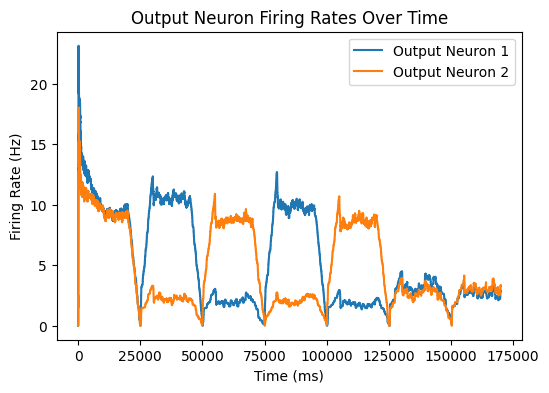

In [87]:
# Plot output
output_history = np.array(sim.output_logger)
plt.figure(figsize=(6,4))
plt.plot(output_history[:, 0], label="Output Neuron 1")
plt.plot(output_history[:, 1], label="Output Neuron 2")
plt.title("Output Neuron Firing Rates Over Time")
plt.xlabel("Time (ms)")
plt.ylabel("Firing Rate (Hz)")
plt.legend()
plt.show()

In [88]:
connectome.M

array([[ 11,  47,  70, ...,   0,   0,   0],
       [  2,   7,  12, ..., 158, 151, 147],
       [  1,   3,  12, ...,   0,   0,   0],
       ...,
       [101, 102, 104, ...,   0,   0,   0],
       [104, 111, 116, ...,   0,   0,   0],
       [113, 114, 121, ...,   0,   0,   0]])

In [89]:
dW = connectome.W - W_initial
# Max and min change
max_dW = np.max(dW)
min_dW = np.min(dW)
print(f"Max change in synaptic weights: {max_dW:.4f}")
print(f"Min change in synaptic weights: {min_dW:.4f}")

Max change in synaptic weights: 0.5670
Min change in synaptic weights: -0.0563


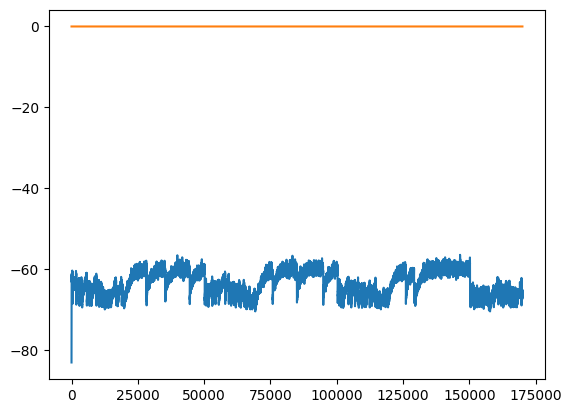

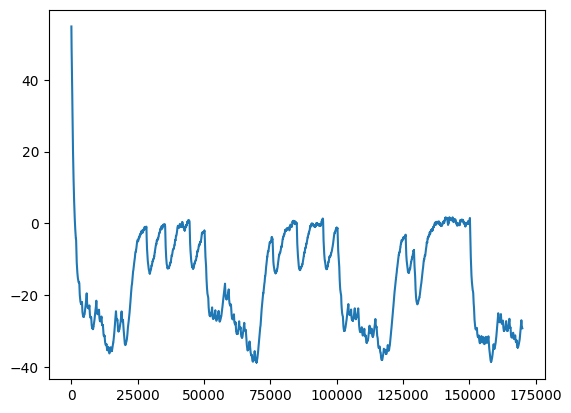

In [90]:
n_idx = 7
t_first = 0
t_last = -1
plt.plot(np.array(sim.stats.Vs)[t_first:t_last,n_idx])
plt.plot(np.array(sim.stats.spikes)[t_first:t_last,n_idx] * 10)
plt.show()
plt.plot(np.array(sim.stats.us)[t_first:t_last,n_idx])
plt.show()